<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Implementaci%C3%B3n_de_Redes_Neuronales_Recurrentes_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementación de Redes Neuronales Recurrentes-Armando Chacón Terrazas**

El objetivo de este ejercicio es implementar una red neuronal recurrente para predecir el valor más bajo de una acción (columna Low) tomando como referencia un historial de valores de días previos. Cada estudiante puede elegir libremente el archivo de la empresa con la que trabajará.


Instrucciones:
División del conjunto de datos

Use los datos desde el inicio hasta el año 2016 como conjunto de entrenamiento.

Use los datos del año 2017 en adelante como conjunto de prueba.

Implementación del modelo

Se proporciona un archivo base de programación que les permitirá:

Leer los archivos de datos.

Construir los conjuntos de entrenamiento y prueba.

Definir y entrenar una red neuronal recurrente.

Pruebas a realizar

Entrene y evalúe un modelo usando celdas LSTM.

Entrene y evalúe un modelo usando celdas GRU.

En ambos casos, realice las pruebas considerando:

Un historial de 30 días previos.

Un historial de 50 días previos.

Resultados a reportar

Registre las curvas comparativas entre los valores esperados y los valores predichos por cada modelo.

Calcule y reporte el valor de RMSE (Root Mean Square Error) para cada prueba.

Compare y discuta los resultados obtenidos entre:

Modelos con LSTM vs GRU.

Uso de 30 días vs 50 días de historial.

# **MÓDULO 1: Importación de librerías**

In [2]:
# Importación de las herramientas y librerías necesarias.
import numpy as np # Para hacer cálculos matemáticos rápidos con matrices.
import matplotlib.pyplot as plt # Para dibujar las gráficas (las líneas de los precios).
plt.style.use('fivethirtyeight') # Le da un estilo visual a las gráficas.
import pandas as pd # Para leer y manipular tablas de datos, como las de Excel.
from sklearn.preprocessing import MinMaxScaler # Para "comprimir" los números entre 0 y 1.
from keras.models import Sequential # Para construir la red neuronal capa por capa.
from keras.layers import Dense, LSTM, Dropout, GRU # Los diferentes "bloques" o neuronas que se usan
from keras.optimizers import SGD, RMSprop # El método que usa la red para corregir sus errores.
import math
from sklearn.metrics import mean_squared_error # Para calificar qué tan bien o mal predijo el modelo.

# **MÓDULO 2: Carga y preparación de datos**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1. Obtener y preparar los datos, esto se hace solo una vez

# Ruta donde esta el archivo CSV en Google Colab.
path_file = '/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/CSCO_2006-01-01_to_2018-01-01.csv'

# Leemos el archivo. Le decimos que la columna 'Date' (Fecha) será nuestro índice.
dataset1 = pd.read_csv(path_file, index_col='Date', parse_dates=['Date'])

# Limpiamos los datos: si hay alguna fila vacía o con error, la eliminamos.
dataset = dataset1.dropna()

# Separamos los datos para ESTUDIAR (Entrenamiento) y para EXAMINAR (Prueba).
# Usamos la columna "Low" (el precio más bajo del día).
training_set = dataset.loc[:'2016', ["Low"]].values  # Todo hasta 2016
test_set = dataset.loc['2017':, ["Low"]].values      # Todo desde 2017 en adelante

# Escalar los datos (MinMaxScaler) - Comprime todos los precios para que valgan entre 0 y 1.
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

print("Datos cargados y preparados exitosamente")

Datos cargados y preparados exitosamente


# **MÓDULO 3: Entrenamiento y Pruebas (Automatización)**


INICIANDO PRUEBA: Modelo LSTM con historial de 30 días

Entrenando la red neuronal...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.0379
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0113
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0091
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0084
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0080
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0067
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0064
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0056
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0048
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0049
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


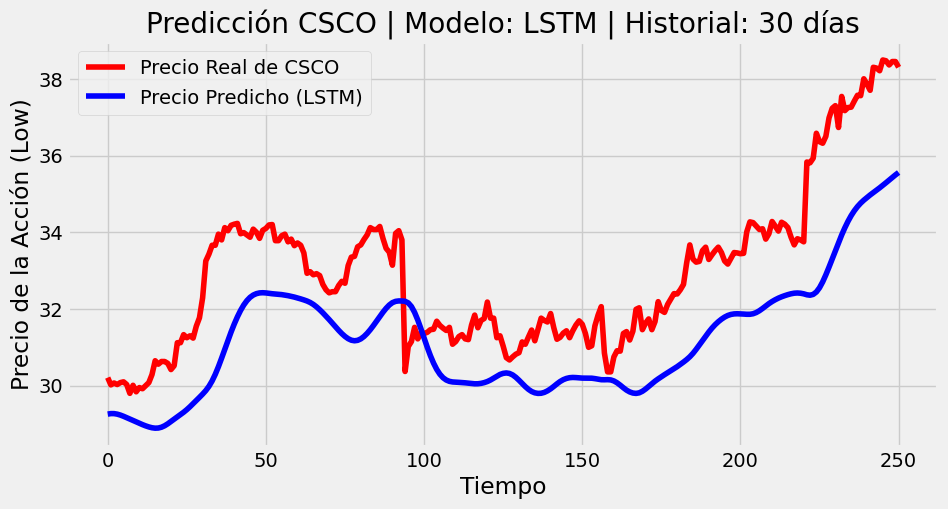

-> FINALIZADO: El RMSE para LSTM con 30 días es: 1.9490

INICIANDO PRUEBA: Modelo LSTM con historial de 50 días

Entrenando la red neuronal...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0486
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0111
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0096
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0077
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0068
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0067
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0057
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0050
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0051
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0043
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


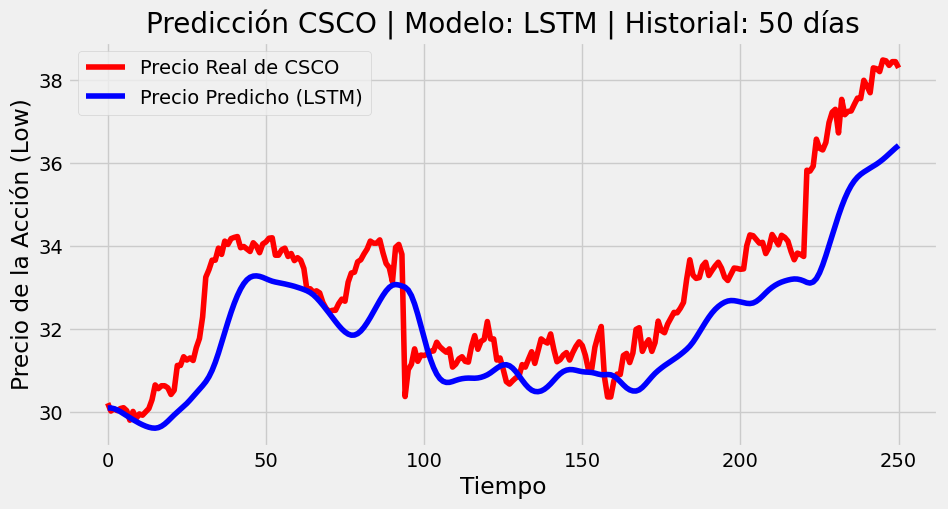

-> FINALIZADO: El RMSE para LSTM con 50 días es: 1.2680

INICIANDO PRUEBA: Modelo GRU con historial de 30 días

Entrenando la red neuronal...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0351
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0090
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0074
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0067
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0049
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0046
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0051
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0039
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0036
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0033


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


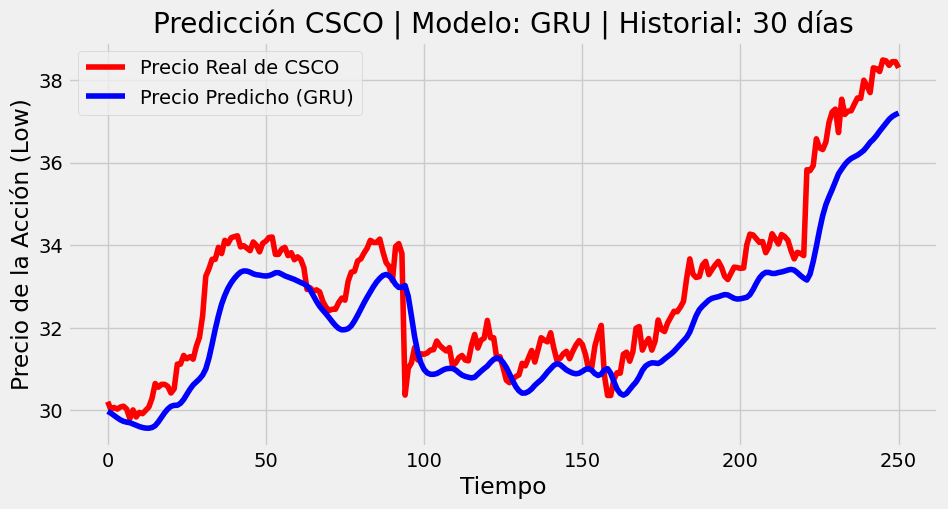

-> FINALIZADO: El RMSE para GRU con 30 días es: 0.9594

INICIANDO PRUEBA: Modelo GRU con historial de 50 días

Entrenando la red neuronal...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 0.0397
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0072
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0072
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0062
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 0.0056
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0047
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0048
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0043
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0038
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0039


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


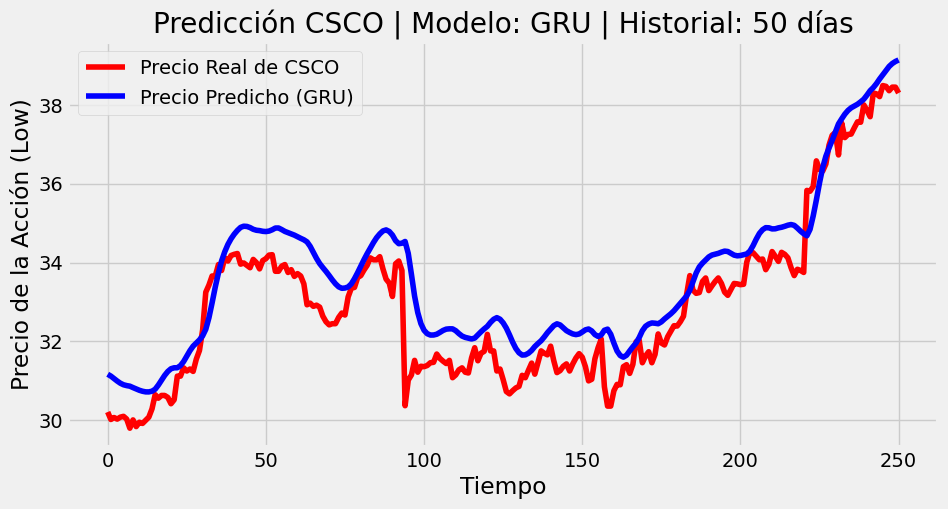

-> FINALIZADO: El RMSE para GRU con 50 días es: 0.8785


In [4]:
# AUTOMATIZACIÓN DE LAS 4 PRUEBAS
# Creamos listas con los parámetros a evaluar
modelos = ['LSTM', 'GRU']
dias_historial = [30, 50]

# Aquí guardaremos los resultados finales para mostrarlos al terminar
resultados_rmse = []

# Este ciclo repetirá todo el proceso 4 veces (2 modelos x 2 historiales)
for TIPO_CELDA in modelos:
    for DIAS_PREVIOS in dias_historial:
        print(f"\n{'='*50}")
        print(f"INICIANDO PRUEBA: Modelo {TIPO_CELDA} con historial de {DIAS_PREVIOS} días")
        print(f"{'='*50}\n")

        # 2. Crear la estructura de aprendizaje para los días actuales del ciclo
        X_train = [] # Aquí guardamos los historiales (ej. los últimos 30 o 50 días)
        y_train = [] # Aquí guardamos la respuesta correcta (el día a predecir)
        N = training_set.shape[0] # Total de datos que tenemos

        for i in range(DIAS_PREVIOS, N):
            X_train.append(training_set_scaled[i-DIAS_PREVIOS:i, 0])
            y_train.append(training_set_scaled[i, 0])

        # Convertimos a matrices matemáticas
        X_train_arr, y_train_arr = np.array(X_train), np.array(y_train)
        # Cambiamos la "forma" de los datos para Keras
        X_train_arr = np.reshape(X_train_arr, (X_train_arr.shape[0], X_train_arr.shape[1], 1))

        # 3. Construir el "Cerebro", La Arquitectura de la Red Neuronal
        regressor = Sequential()

        if TIPO_CELDA == 'LSTM':
            # Capa 1: Agregamos 50 neuronas LSTM
            regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_arr.shape[1], 1)))
            regressor.add(Dropout(0.2)) # Apagamos el 20% de neuronas para evitar memorización
            # Capa 2
            regressor.add(LSTM(units=50, return_sequences=True))
            regressor.add(Dropout(0.2))
            # Capa 3
            regressor.add(LSTM(units=50, return_sequences=True))
            regressor.add(Dropout(0.2))
            # Capa 4
            regressor.add(LSTM(units=50))
            regressor.add(Dropout(0.2))

        elif TIPO_CELDA == 'GRU':
            # Capas usando celdas GRU
            regressor.add(GRU(units=50, return_sequences=True, input_shape=(X_train_arr.shape[1], 1)))
            regressor.add(Dropout(0.2))
            regressor.add(GRU(units=50, return_sequences=True))
            regressor.add(Dropout(0.2))
            regressor.add(GRU(units=50, return_sequences=True))
            regressor.add(Dropout(0.2))
            regressor.add(GRU(units=50))
            regressor.add(Dropout(0.2))

        # Capa de salida: 1 sola neurona que nos dará el precio predicho
        regressor.add(Dense(units=1, activation='linear'))

        # 4. Compilar y Entrenar
        regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

        print("Entrenando la red neuronal...")
        # Entrenamos la red con 10 pasadas (epochs)
        regressor.fit(X_train_arr, y_train_arr, epochs=10, batch_size=32, verbose=1)

        # 5. Preparar el examen (Datos de prueba de 2017 en adelante)
        dataset_total = pd.concat((dataset["Low"][:'2016'], dataset["Low"]['2017':]), axis=0)
        inputs = dataset_total[len(dataset_total) - len(test_set) - DIAS_PREVIOS:].values
        inputs = inputs.reshape(-1,1)
        inputs = sc.transform(inputs) # Escalar de 0 a 1

        X_test = []
        N1 = inputs.shape[0]
        for i in range(DIAS_PREVIOS, N1):
            X_test.append(inputs[i-DIAS_PREVIOS:i, 0])
        X_test = np.array(X_test)
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

        # 6. Hacer la predicción
        predicted_stock_price = regressor.predict(X_test)
        # Descomprimir los datos a precios en dólares reales
        predicted_stock_price = sc.inverse_transform(predicted_stock_price)

        # 7. Visualizar los resultados y calificar
        plt.figure(figsize=(10,5))
        plt.plot(test_set, color='red', label='Precio Real de CSCO')
        plt.plot(predicted_stock_price, color='blue', label=f'Precio Predicho ({TIPO_CELDA})')
        plt.title(f'Predicción CSCO | Modelo: {TIPO_CELDA} | Historial: {DIAS_PREVIOS} días')
        plt.xlabel('Tiempo')
        plt.ylabel('Precio de la Acción (Low)')
        plt.legend()
        plt.show() # Mostrará la gráfica de esta iteración

        # Calcular RMSE
        rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
        print(f"-> FINALIZADO: El RMSE para {TIPO_CELDA} con {DIAS_PREVIOS} días es: {rmse:.4f}")

        # Guardamos el resultado para el resumen final
        resultados_rmse.append(f"Modelo: {TIPO_CELDA} | Días: {DIAS_PREVIOS} | RMSE: {rmse:.4f}")

# **MÓDULO 4: Reporte de Resultados**

In [5]:
print("\n" + "="*50)
print("RESUMEN DE LAS 4 PRUEBAS")
print("="*50)
for res in resultados_rmse:
    print(res)
print("="*50)


RESUMEN DE LAS 4 PRUEBAS
Modelo: LSTM | Días: 30 | RMSE: 1.9490
Modelo: LSTM | Días: 50 | RMSE: 1.2680
Modelo: GRU | Días: 30 | RMSE: 0.9594
Modelo: GRU | Días: 50 | RMSE: 0.8785
